In [1]:
import torch
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch version: 2.7.1+cu126
CUDA available: True


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type != 'cuda':
    raise SystemError('GPU device not found')
print(f'Found GPU: {torch.cuda.get_device_name(0)}')

Found GPU: NVIDIA GeForce RTX 3060


In [3]:
!pip install ipython-autotime --quiet
%load_ext autotime

time: 0 ns (started: 2026-04-05 23:48:14 +06:00)


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet50_Weights

from sklearn.metrics import confusion_matrix, roc_curve, auc

time: 3.28 s (started: 2026-04-05 23:48:14 +06:00)


## Customizable Variables

### Dataset

In [5]:
dataset_base_path = r'F:\image_processing\dataset\Negative'
number_of_classes = 2   # 1 sigmoid output for binary classification
img_height = 64
img_width  = 64
batch_size = 16

time: 0 ns (started: 2026-04-05 23:48:18 +06:00)


### Pre-trained Model

In [6]:
# Load ResNet101 with ImageNet weights
backbone = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

time: 282 ms (started: 2026-04-05 23:48:18 +06:00)


### Save File Paths

In [7]:
save_dir = r'F:\image_processing\modelOutput\NegativeModel'
os.makedirs(save_dir, exist_ok=True)

training_model_save_path          = os.path.join(save_dir, 'training_model.pth')
training_history_save_path        = os.path.join(save_dir, 'training_history.csv')
training_history_plot_save_path   = os.path.join(save_dir, 'training_history.png')
training_confusion_matrix_save_path = os.path.join(save_dir, 'training_confusion_matrix.png')
training_roc_curve_save_path      = os.path.join(save_dir, 'training_roc_curve.png')

accuracy_loss_csv_path    = os.path.join(save_dir, 'AccuracyLossCurves.csv')
roc_auroc_csv_path        = os.path.join(save_dir, 'ROCandAUROC.csv')
confusion_matrix_csv_path = os.path.join(save_dir, 'ConfusionMat.csv')

time: 0 ns (started: 2026-04-05 23:48:18 +06:00)


### Hyper Parameters (Initial Training)

**Note:** `nn.BCELoss` is used for Binary Classification with a sigmoid output.

In [8]:
training_epochs        = 30
training_learning_rate = 0.0001
training_loss          = nn.BCELoss()   # Binary Cross Entropy for sigmoid output
training_patience      = 5              # EarlyStopping patience

time: 0 ns (started: 2026-04-05 23:48:18 +06:00)


## Load and Preprocess Data

In [9]:
def generate_dataset(dataset_base_path, batch_size, img_height, img_width):
    """
    Generates PyTorch DataLoaders for train, validation, and test splits.

    Args:
    - dataset_base_path (str): Root path containing Train / Validation / Test subfolders.
    - batch_size (int): Batch size.
    - img_height (int): Image height.
    - img_width (int): Image width.

    Returns:
    - train_loader, val_loader, test_loader (DataLoader)
    - class_names (list[str])
    """
    # ImageNet normalization (matches ResNet101 pre-training)
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    train_transform = transforms.Compose([
        transforms.Resize((img_height, img_width)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((img_height, img_width)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_dataset = datasets.ImageFolder(os.path.join(dataset_base_path, 'Train'),      transform=train_transform)
    val_dataset   = datasets.ImageFolder(os.path.join(dataset_base_path, 'Validation'), transform=eval_transform)
    test_dataset  = datasets.ImageFolder(os.path.join(dataset_base_path, 'Test'),       transform=eval_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    class_names = train_dataset.classes
    return train_loader, val_loader, test_loader, class_names

time: 0 ns (started: 2026-04-05 23:48:18 +06:00)


In [10]:
train_loader, val_loader, test_loader, class_names = generate_dataset(
    dataset_base_path, batch_size, img_height, img_width
)
print('Classes:', class_names)

Classes: ['AnnualCrop_Negative', 'PermanentCrop_Negative']
time: 15 ms (started: 2026-04-05 23:48:18 +06:00)


## Model Architecture

In [11]:
def generate_model(backbone):
    """
    Builds a binary classification model from a ResNet101 backbone.

    Freezes all backbone layers and replaces the final FC layer with a
    custom head: Linear(2048->512) -> Dropout(0.5) -> Linear(512->256)
    -> Dropout(0.3) -> Linear(256->1) -> Sigmoid.

    Args:
    - backbone (nn.Module): Pre-trained ResNet101.

    Returns:
    - model (nn.Module)
    """
    # Freeze all backbone parameters
    for param in backbone.parameters():
        param.requires_grad = False

    in_features = backbone.fc.in_features  # 2048 for ResNet101

    # Replace the classifier head
    backbone.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1),
        nn.Sigmoid(),   # Binary output probability
    )

    return backbone

time: 0 ns (started: 2026-04-05 23:48:18 +06:00)


In [12]:
model = generate_model(backbone).to(device)

time: 281 ms (started: 2026-04-05 23:48:18 +06:00)


## Initial Training

In [13]:
def train(model, epochs, learning_rate, criterion, train_loader, val_loader,
          model_save_path, history_save_path, patience, device):
    """
    Trains the model with early stopping, LR scheduling, and best-model checkpointing.

    Args:
    - model        : nn.Module
    - epochs       : int
    - learning_rate: float
    - criterion    : loss function (BCELoss)
    - train_loader : DataLoader
    - val_loader   : DataLoader
    - model_save_path  : str  - path to save best model (.pth)
    - history_save_path: str  - path to save training history CSV
    - patience     : int  - early stopping patience
    - device       : torch.device

    Returns:
    - history (dict): keys loss, val_loss, accuracy, val_accuracy
    """
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

    best_val_loss  = float('inf')
    best_weights   = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        # ---- Training phase ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)  # shape (B,1)

            optimizer.zero_grad()
            outputs = model(images)          # shape (B,1), values in [0,1]
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds  = (outputs >= 0.5).float()
            correct += (preds == labels).sum().item()
            total   += images.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # ---- Validation phase ----
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                outputs  = model(images)
                loss     = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                preds    = (outputs >= 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total   += images.size(0)

        val_loss /= val_total
        val_acc   = val_correct / val_total

        scheduler.step(val_loss)

        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)

        print(f'Epoch [{epoch+1}/{epochs}]  '
              f'Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  '
              f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}')

        # ---- Checkpoint: save best model ----
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_weights   = copy.deepcopy(model.state_dict())
            torch.save(best_weights, model_save_path)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    # Restore best weights
    model.load_state_dict(torch.load(model_save_path))

    # Save history to CSV
    pd.DataFrame(history).to_csv(history_save_path, index=False)

    return history

time: 0 ns (started: 2026-04-05 23:48:18 +06:00)


In [14]:
training_history = train(
    model,
    training_epochs,
    training_learning_rate,
    training_loss,
    train_loader,
    val_loader,
    training_model_save_path,
    training_history_save_path,
    training_patience,
    device
)

Epoch [1/30]  Loss: 0.4476  Acc: 0.8147  Val Loss: 0.2163  Val Acc: 0.9140
Epoch [2/30]  Loss: 0.3043  Acc: 0.8803  Val Loss: 0.2058  Val Acc: 0.9160
Epoch [3/30]  Loss: 0.2672  Acc: 0.8880  Val Loss: 0.1822  Val Acc: 0.9200
Epoch [4/30]  Loss: 0.2552  Acc: 0.8987  Val Loss: 0.1949  Val Acc: 0.9280
Epoch [5/30]  Loss: 0.2660  Acc: 0.8917  Val Loss: 0.2794  Val Acc: 0.8910
Epoch [6/30]  Loss: 0.2447  Acc: 0.9060  Val Loss: 0.1732  Val Acc: 0.9300
Epoch [7/30]  Loss: 0.2459  Acc: 0.9050  Val Loss: 0.1651  Val Acc: 0.9360
Epoch [8/30]  Loss: 0.2394  Acc: 0.9010  Val Loss: 0.2002  Val Acc: 0.9180
Epoch [9/30]  Loss: 0.2136  Acc: 0.9150  Val Loss: 0.1823  Val Acc: 0.9270
Epoch [10/30]  Loss: 0.2417  Acc: 0.9067  Val Loss: 0.1940  Val Acc: 0.9250
Epoch [11/30]  Loss: 0.2205  Acc: 0.9123  Val Loss: 0.1928  Val Acc: 0.9250
Epoch [12/30]  Loss: 0.2182  Acc: 0.9083  Val Loss: 0.2207  Val Acc: 0.9160
Early stopping at epoch 12
time: 3min 59s (started: 2026-04-05 23:48:18 +06:00)


### Evaluate the model on test dataset

In [15]:
def evaluate(model, loader, criterion, device):
    """
    Evaluates model on a DataLoader.

    Returns:
    - dict with loss and accuracy
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds    = (outputs >= 0.5).float()
            correct += (preds == labels).sum().item()
            total   += images.size(0)

    print(f'Test Loss: {total_loss/total:.4f}  Test Accuracy: {correct/total:.4f}')
    return {'loss': total_loss / total, 'accuracy': correct / total}


evaluate(model, test_loader, training_loss, device)

Test Loss: 0.1643  Test Accuracy: 0.9350


{'loss': 0.16431154109537602, 'accuracy': 0.935}

time: 10.6 s (started: 2026-04-05 23:52:17 +06:00)


## Evaluation Metrics

### Training History Plot

In [16]:
def plot_history(history, save_path):
    """
    Plots training and validation loss / accuracy over epochs.

    Args:
    - history  : dict with keys loss, val_loss, accuracy, val_accuracy
    - save_path: str
    """
    fig, (ax1, ax2) = plt.subplots(2)
    fig.set_size_inches(18.5, 10.5)

    ax1.set_title('Loss')
    ax1.plot(history['loss'],     label='Train')
    ax1.plot(history['val_loss'], label='Validation')
    ax1.set_ylabel('Loss')
    ax1.set_ylim([0, np.ceil(max(history['loss'] + history['val_loss']))])
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.set_title('Accuracy')
    ax2.plot(history['accuracy'],     label='Train')
    ax2.plot(history['val_accuracy'], label='Validation')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim([0, 1])
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.savefig(save_path)
    plt.show()

time: 0 ns (started: 2026-04-05 23:52:28 +06:00)


### Confusion Matrix

In [17]:
def plot_confusion_matrix(loader, model, class_names, save_path, device):
    """
    Computes and plots the confusion matrix for binary classification.

    Args:
    - loader     : DataLoader
    - model      : nn.Module (sigmoid output)
    - class_names: list[str]
    - save_path  : str
    - device     : torch.device

    Returns:
    - cm (ndarray)
    """
    model.eval()
    actual_labels, predicted_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images).cpu().squeeze(1)       # shape (B,)
            preds   = (outputs >= 0.5).long()
            actual_labels.extend(labels.numpy())
            predicted_labels.extend(preds.numpy())

    cm = confusion_matrix(actual_labels, predicted_labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted labels')
    plt.ylabel('Actual labels')
    plt.title('Confusion Matrix')
    plt.savefig(save_path)
    plt.show()
    return cm

time: 0 ns (started: 2026-04-05 23:52:28 +06:00)


### ROC Curve

In [18]:
def plot_roc_curve(model, test_loader, class_names, save_path, csv_path, is_fine_tuning, device):
    """
    Plots the ROC curve and computes AUC for binary classification.

    Args:
    - model         : nn.Module (sigmoid output)
    - test_loader   : DataLoader
    - class_names   : list[str]
    - save_path     : str
    - csv_path      : str  - path to append ROC data
    - is_fine_tuning: bool
    - device        : torch.device
    """
    model.eval()
    y_true, y_scores = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(device)
            outputs = model(images).cpu().squeeze(1)   # probabilities in [0,1]
            y_true.extend(labels.numpy().astype(int))
            y_scores.extend(outputs.numpy())

    y_true   = np.array(y_true)
    y_scores = np.array(y_scores)

    fpr, tpr, _ = roc_curve(y_true, y_scores, pos_label=1)
    roc_auc     = auc(fpr, tpr)
    print(f'\nFinal ROC AUC: {roc_auc:.3f}\n')

    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'navy', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.savefig(save_path)
    plt.show()

    # Save to CSV
    file_exists = os.path.isfile(csv_path)
    with open(csv_path, mode='a' if file_exists else 'w', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(['Class', 'FPR', 'TPR', 'AUC'])
        writer.writerow(['Fine Tuning Stage' if is_fine_tuning else 'Training Stage'])
        for fpr_val, tpr_val in zip(fpr, tpr):
            writer.writerow([class_names[1], fpr_val, tpr_val, roc_auc])

time: 0 ns (started: 2026-04-05 23:52:28 +06:00)


## Evaluate Initial Training Results

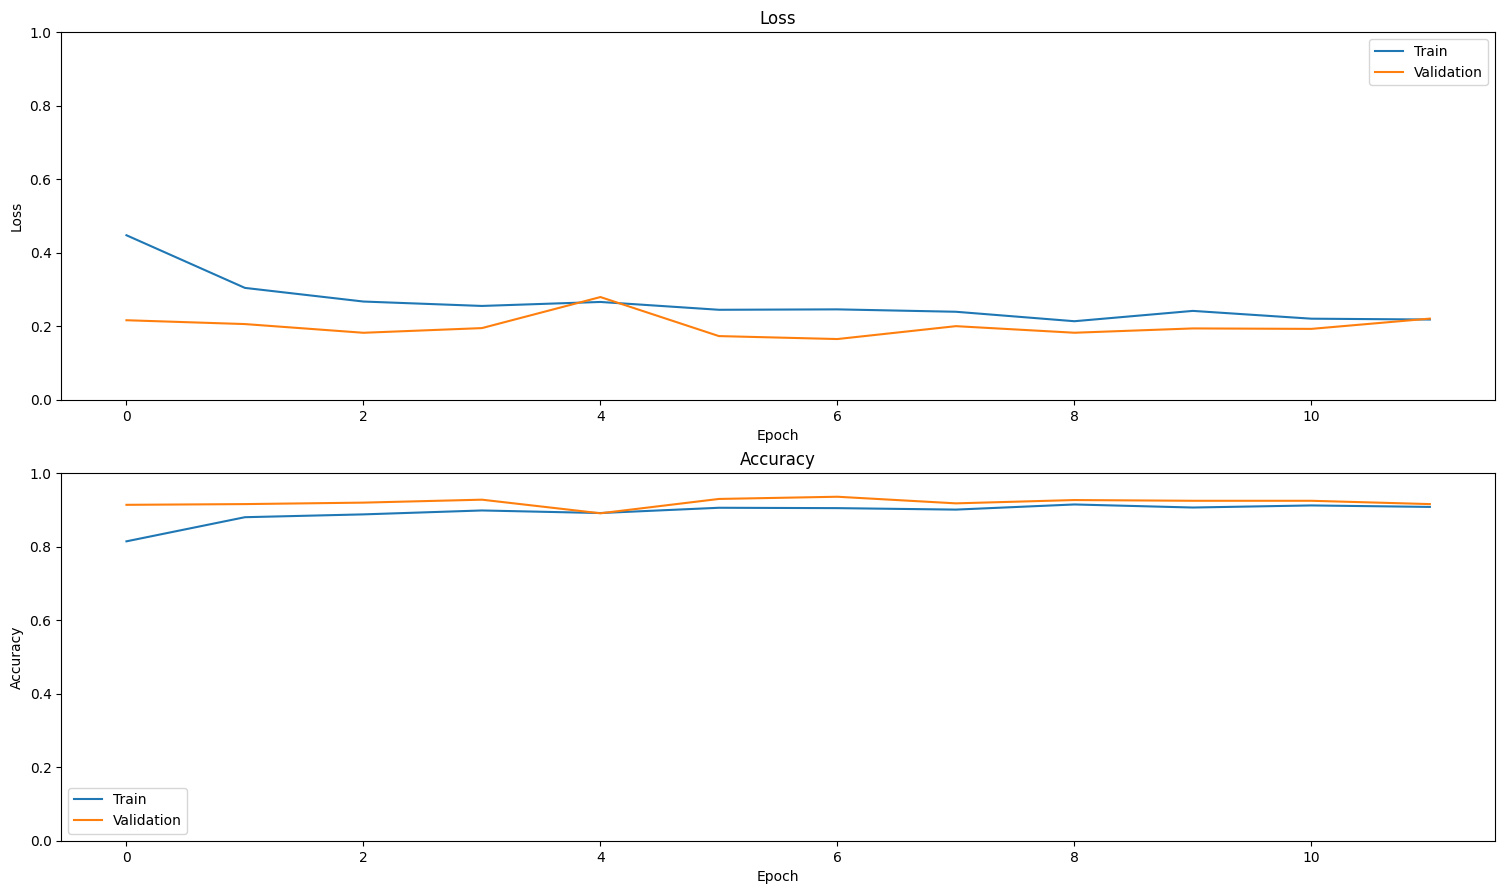

time: 344 ms (started: 2026-04-05 23:52:28 +06:00)


In [19]:
plot_history(training_history, training_history_plot_save_path)

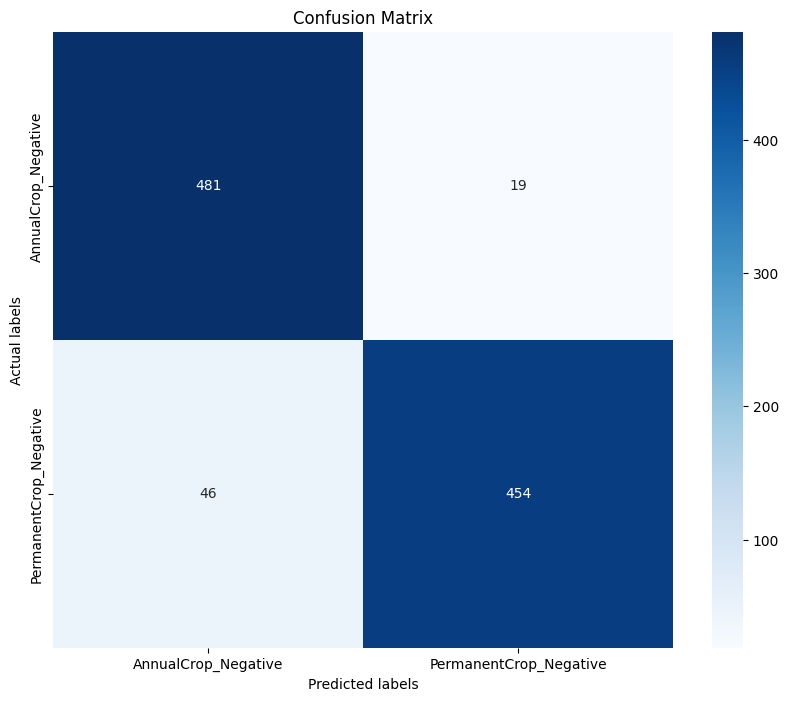

time: 9.09 s (started: 2026-04-05 23:52:28 +06:00)


In [20]:
training_confusion_matrix = plot_confusion_matrix(
    test_loader, model, class_names, training_confusion_matrix_save_path, device
)


Final ROC AUC: 0.985



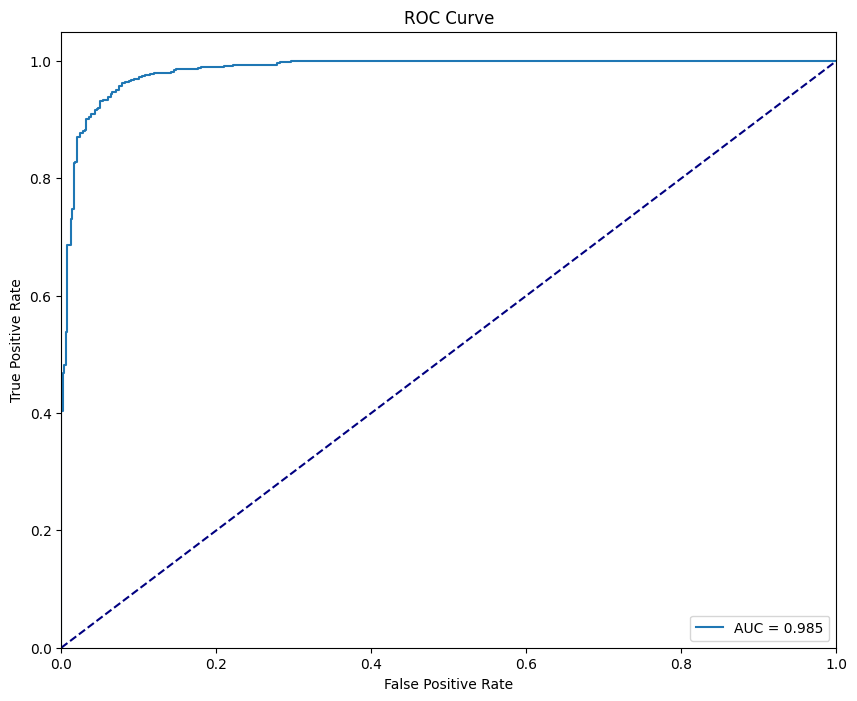

time: 8.69 s (started: 2026-04-05 23:52:37 +06:00)


In [21]:
plot_roc_curve(
    model, test_loader, class_names,
    training_roc_curve_save_path, roc_auroc_csv_path,
    is_fine_tuning=False, device=device
)

## Grad-CAM Implementation

Grad-CAM highlights which image regions drove the model's prediction by computing gradients of the output with respect to the last convolutional feature map.

Steps:
1. Register a forward hook to capture the last conv layer's output (feature maps).
2. Register a backward hook to capture the gradients flowing back into that layer.
3. Global-average-pool the gradients → per-channel importance weights.
4. Weight the feature maps and sum → heatmap.
5. ReLU + normalise → overlay on the original image.

In [22]:
def make_gradcam_heatmap(img_tensor, model, device):
    """
    Produces a Grad-CAM heatmap for a single image.

    Uses the last Conv2d layer found in the model backbone.

    Args:
    - img_tensor : torch.Tensor, shape (1, C, H, W), already on CPU
    - model      : nn.Module
    - device     : torch.device

    Returns:
    - heatmap (np.ndarray), shape (H', W'), values in [0, 1]
    """
    model.eval()

    # Find the last Conv2d layer in the backbone (before the FC head)
    last_conv_layer = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            last_conv_layer = module

    if last_conv_layer is None:
        raise ValueError('No Conv2d layer found in model.')

    feature_maps = []
    gradients    = []

    def forward_hook(module, input, output):
        feature_maps.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    fh = last_conv_layer.register_forward_hook(forward_hook)
    bh = last_conv_layer.register_full_backward_hook(backward_hook)

    img_tensor = img_tensor.to(device).requires_grad_(True)
    output = model(img_tensor)          # shape (1,1)
    model.zero_grad()
    output.backward()                   # grad of sigmoid output w.r.t. feature maps

    fh.remove()
    bh.remove()

    grads = gradients[0].detach().cpu()         # (1, C, H', W')
    fmaps = feature_maps[0].detach().cpu()      # (1, C, H', W')

    weights = grads.mean(dim=(2, 3), keepdim=True)  # Global Average Pooling
    cam     = (weights * fmaps).sum(dim=1).squeeze(0)  # (H', W')
    cam     = torch.relu(cam)

    # Normalise to [0, 1]
    cam -= cam.min()
    if cam.max() > 0:
        cam /= cam.max()

    return cam.numpy()

time: 0 ns (started: 2026-04-05 23:52:46 +06:00)


In [23]:
def display_gradcam(img_np, heatmap, alpha=0.4):
    """
    Overlays the Grad-CAM heatmap on the original image.

    Args:
    - img_np  : np.ndarray uint8, shape (H, W, 3)
    - heatmap : np.ndarray float, shape (H', W') in [0,1]
    - alpha   : float, heatmap opacity

    Returns:
    - superimposed (np.ndarray uint8)
    """
    import cv2
    heatmap_uint8  = np.uint8(255 * heatmap)
    heatmap_color  = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color  = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    heatmap_resized = cv2.resize(heatmap_color, (img_np.shape[1], img_np.shape[0]))
    superimposed   = (heatmap_resized * alpha + img_np * (1 - alpha)).astype(np.uint8)
    return superimposed

time: 0 ns (started: 2026-04-05 23:52:46 +06:00)


### Load Specific Images for Grad-CAM

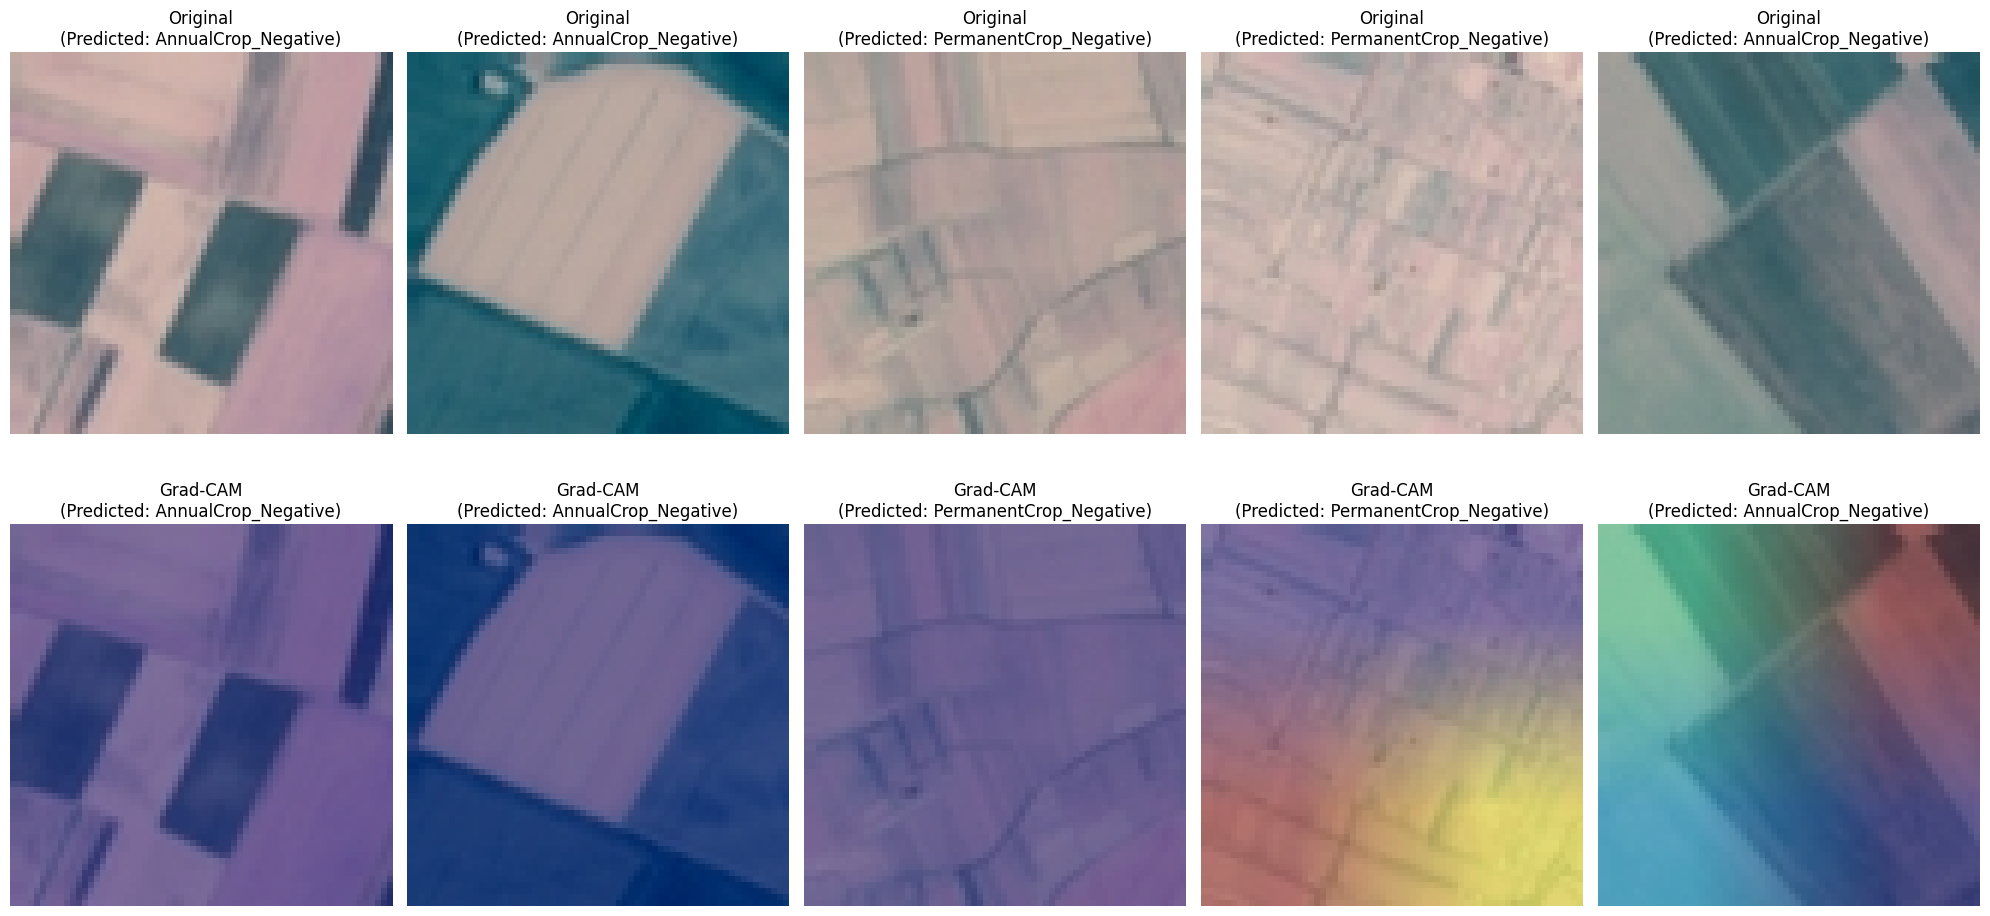

Grad-CAM images saved to: F:\image_processing\modelOutput\NegativeModel\Gradcam
time: 578 ms (started: 2026-04-05 23:52:46 +06:00)


In [24]:
from PIL import Image as PILImage

specific_image_paths = [
    r'F:\image_processing\dataset\Negative\train\AnnualCrop_Negative\00045.png',
    r'F:\image_processing\dataset\Negative\train\AnnualCrop_Negative\00177.png',
    r'F:\image_processing\dataset\Negative\train\PermanentCrop_Negative\00081.png',
    r'F:\image_processing\dataset\Negative\train\PermanentCrop_Negative\00159.png',
    r'F:\image_processing\dataset\Negative\validation\AnnualCrop_Negative\02101.png'
]

gradcam_output_dir = os.path.join(save_dir, 'Gradcam')
os.makedirs(gradcam_output_dir, exist_ok=True)

# ImageNet normalization (must match training)
preprocess = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

plt.figure(figsize=(20, 10))

for i, img_path in enumerate(specific_image_paths):
    pil_img   = PILImage.open(img_path).convert('RGB')
    img_np    = np.array(pil_img.resize((img_width, img_height)), dtype=np.uint8)
    img_tensor = preprocess(pil_img).unsqueeze(0)   # (1, 3, H, W)

    # Prediction
    model.eval()
    with torch.no_grad():
        prob = model(img_tensor.to(device)).item()
    predicted_class_index = int(prob >= 0.5)
    predicted_class_name  = class_names[predicted_class_index]

    # Grad-CAM
    heatmap    = make_gradcam_heatmap(img_tensor, model, device)
    gradcam_img = display_gradcam(img_np, heatmap)

    # Save
    base_name = os.path.basename(img_path).split('.')[0]
    PILImage.fromarray(img_np).save(
        os.path.join(gradcam_output_dir, f'{base_name}_original_predicted_{predicted_class_name}.png')
    )
    PILImage.fromarray(gradcam_img).save(
        os.path.join(gradcam_output_dir, f'{base_name}_gradcam_predicted_{predicted_class_name}.png')
    )

    # Display
    plt.subplot(2, len(specific_image_paths), i + 1)
    plt.imshow(img_np)
    plt.title(f'Original\n(Predicted: {predicted_class_name})')
    plt.axis('off')

    plt.subplot(2, len(specific_image_paths), len(specific_image_paths) + i + 1)
    plt.imshow(gradcam_img)
    plt.title(f'Grad-CAM\n(Predicted: {predicted_class_name})')
    plt.axis('off')

plt.tight_layout()
plt.show()
print(f'Grad-CAM images saved to: {gradcam_output_dir}')